In [65]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import torch
print(torch.cuda.is_available())

# for RTX 5080
"""pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128"""

import numpy as np
import librosa
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

# --- 1. Configuration ---
DATA_DIR = r"E:\KOULU\IRMAS\IRMAS-TrainingData" 
TEST_DIR = r"E:\KOULU\IRMAS\IRMAS-TestingData\Part1Part2Part3"
BATCH_SIZE = 32
# vgg16 expects 3 channels RGB
IMG_SHAPE = (128, 130, 3)
PRED_THRESHOLD = 0.20

instrument_list = ['cel', 'cla', 'flu', 'gac', 'gel', 'org', 'pia', 'sax', 'tru', 'vio', 'voi']
label_map = {inst: i for i, inst in enumerate(instrument_list)}
NUM_CLASSES = len(instrument_list)

instrument_map = {
    'cel': 'Celesta',         'cla': 'Clarinet',        'flu': 'Flute',
    'gac': 'Acoustic Guitar', 'gel': 'Electric Guitar', 'org': 'Organ',
    'pia': 'Piano',           'sax': 'Saxophone',       'tru': 'Trumpet',
    'vio': 'Violin',          'voi': 'Human Voice'
}

True


In [66]:
# --- 2. File Discovery ---
file_paths = []
labels = []

for root, dirs, files in os.walk(DATA_DIR):
    folder_name = os.path.basename(root)
    if folder_name in label_map:
        idx = label_map[folder_name]
        for file in files:
            if file.endswith(".wav"):
                file_paths.append(os.path.join(root, file))
                # Change: labels are float32 vectors of shape (11,), each position represents one instrument (0.0 or 1.0)
                label_vec = np.zeros(NUM_CLASSES, dtype=np.float32)
                label_vec[idx] = 1.0
                labels.append(label_vec)

labels = np.array(labels, dtype=np.float32)  # Change: shape (N, 11) instead of (N,)
print(f"Found {len(file_paths)} training files")

# Split training data to train/val
# Change: stratify uses argmax because labels are now vectors
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42,
    stratify=np.argmax(labels, axis=1)
)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")

# Compute weights (Added in v4)
# Convert one-hot to integer labels for weight computation
train_labels_int = np.argmax(train_labels, axis=1)
classes = np.unique(train_labels_int)
weights = compute_class_weight('balanced', classes=classes, y=train_labels_int)
class_weight_dict = dict(enumerate(weights))

print("Class weights:", class_weight_dict)

Found 6705 training files
Train: 5364 | Val: 1341
Class weights: {0: np.float64(1.5730205278592375), 1: np.float64(1.207020702070207), 2: np.float64(1.3507932510702594), 3: np.float64(0.9561497326203209), 4: np.float64(0.8020334928229665), 5: np.float64(0.8931068931068931), 6: np.float64(0.8451236804789665), 7: np.float64(0.9733260751224823), 8: np.float64(1.0577795306645632), 9: np.float64(1.0509404388714734), 10: np.float64(0.7839812920198772)}


In [67]:
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 130, 3))
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 128, 130, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 130, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 130, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 65, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 65, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

Custom SpecAugment layer to augment our data. Mimics real-world edge cases. The augmentation policy consists of warping the features, masking blocks of frequency channels, and masking blocks of time steps.

In [68]:
import torch.nn as nn

@keras.saving.register_keras_serializable()
class SimpleSpecAugment(nn.Module):
    """PyTorch-native SpecAugment for use with Keras+Torch backend."""
    
    def __init__(self, time_masks=3, freq_masks=3, time_mask_param=50, 
                 freq_mask_param=25, noise_std=0.01):
        super().__init__()
        self.time_masks = time_masks
        self.freq_masks = freq_masks
        self.time_mask_param = time_mask_param
        self.freq_mask_param = freq_mask_param
        self.noise_std = noise_std
        
    def forward(self, inputs, training=True):
        if not training:
            return inputs
            
        # inputs shape: (batch, height, width, channels)
        result = inputs.clone()
        batch_size, h, w, c = result.shape

        # Add Gaussian noise
        if self.noise_std > 0:
            noise = torch.randn_like(result) * self.noise_std
            result = result + noise
        
        # Frequency masking (along height dimension)
        for _ in range(self.freq_masks):
            # Random mask size and position for each batch item
            mask_size = torch.randint(0, self.freq_mask_param, (1,)).item()
            if mask_size >= h:
                continue
                
            mask_start = torch.randint(0, h - mask_size, (1,)).item()
            
            # Apply mask
            result[:, mask_start:mask_start + mask_size, :, :] = 0
        
        # Time masking (along width dimension)
        for _ in range(self.time_masks):
            mask_size = torch.randint(0, self.time_mask_param, (1,)).item()
            if mask_size >= w:
                continue
                
            mask_start = torch.randint(0, w - mask_size, (1,)).item()
            
            # Apply mask
            result[:, :, mask_start:mask_start + mask_size, :] = 0
            
        return result
    
    def get_config(self):
        """Returns the configuration of the layer for serialization."""
        return {
            'time_masks': self.time_masks,
            'freq_masks': self.freq_masks,
            'time_mask_param': self.time_mask_param,
            'freq_mask_param': self.freq_mask_param,
            'noise_std': self.noise_std,
        }

Wrapper to enable sequential Keras model use with SpecAug.

In [69]:
@keras.saving.register_keras_serializable()
class SpecAugmentWrapper(tf.keras.layers.Layer):
    """Wrapper that applies SpecAugment using PyTorch operations."""
    
    def __init__(self, time_masks=2, freq_masks=2, time_mask_param=40, freq_mask_param=20, noise_std=0.01, **kwargs):
        super().__init__(**kwargs)
        self.time_masks = time_masks
        self.freq_masks = freq_masks
        self.time_mask_param = time_mask_param
        self.freq_mask_param = freq_mask_param
        self.noise_std = noise_std
        # Create the PyTorch module
        self.specaugment = SimpleSpecAugment(
            time_masks, freq_masks, time_mask_param, freq_mask_param, noise_std
        )
    
    def call(self, inputs, training=None):
        if training:
            # Apply SpecAugment
            return self.specaugment(inputs, training=True)
        return inputs
    
    def get_config(self):
        """Returns the configuration of the layer for serialization."""
        config = super().get_config()
        config.update({
            'time_masks': self.time_masks,
            'freq_masks': self.freq_masks,
            'time_mask_param': self.time_mask_param,
            'freq_mask_param': self.freq_mask_param,
            'noise_std': self.noise_std,
        })
        return config
    
    @classmethod
    def from_config(cls, config):
        """Creates the layer from its configuration."""
        return cls(**config)

In [70]:
# Converts raw .wav files into normalized Mel-spectrogram images for the CNN to "see"
def process_audio(file_path, label):
    def _parse_audio(fp):
        fp = fp.numpy().decode('utf-8')
        audio, _ = librosa.load(fp, sr=22050, duration=3.0)
        if len(audio) < 66150:
            audio = np.pad(audio, (0, 66150 - len(audio)))
        
        spec = librosa.feature.melspectrogram(y=audio, sr=22050, n_mels=128)
        spec_db = librosa.power_to_db(spec, ref=np.max)
        spec_db = (spec_db + 80.0) / 80.0
        spec_db = np.clip(spec_db, 0, 1)
        
        # Return as 3-channel (RGB) by repeating the grayscale image 3 times
        # This allows VGG16 to process it properly
        spec_db_rgb = np.stack([spec_db, spec_db, spec_db], axis=-1)
        return spec_db_rgb.astype(np.float32)

    [image,] = tf.py_function(_parse_audio, [file_path], [tf.float32])
    image.set_shape((128, 130, 3))  # Now 3 channels for VGG16
    
    return image, label

# Builds an optimized, shuffled, and batched data pipeline to feed the GPU efficiently
# Build dataset with SpecAugment augmentation
def make_dataset(paths, labels, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.shuffle(len(paths))
    ds = ds.map(process_audio, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Apply SpecAugment during training only
    if augment:
        def augment_with_specaugment(image, label):
            # SpecAugment expects shape (128, 130, 3)
            image = tf.expand_dims(image, axis=0)  # Add batch dimension
            # We need to use the wrapper properly - will handle in feature extraction
            return image, label
        ds = ds.map(augment_with_specaugment, num_parallel_calls=tf.data.AUTOTUNE)
    
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# Create datasets WITHOUT SpecAugment first for consistent feature extraction
train_ds_raw = make_dataset(train_paths, train_labels, augment=False)
val_ds_raw = make_dataset(val_paths, val_labels, augment=False)

In [71]:
# Create test dataset
test_files = sorted([f for f in os.listdir(TEST_DIR) if f.endswith('.wav')])
test_paths = [os.path.join(TEST_DIR, f) for f in test_files]

test_labels = []
for f in test_files:
    txt_path = os.path.join(TEST_DIR, os.path.splitext(f)[0] + '.txt')
    label_vec = np.zeros(NUM_CLASSES, dtype=np.float32)
    if os.path.exists(txt_path):
        with open(txt_path, 'r') as t:
            labels_in_file = [item.strip() for item in t.read().split()]
            for code in labels_in_file:
                if code in label_map:
                    label_vec[label_map[code]] = 1.0
    test_labels.append(label_vec)
test_labels = np.array(test_labels)

test_ds = make_dataset(test_paths, test_labels, augment=False)

In [72]:
def get_features_with_specaugment(dataset, conv_base, apply_specaugment=False):
    """
    Extract features from VGG16 with optional SpecAugment augmentation.
    
    Args:
        dataset: tf.data.Dataset yielding (image, label) batches
        conv_base: VGG16 model for feature extraction
        apply_specaugment: If True, apply SpecAugment to images before feature extraction
        
    Returns:
        all_features: numpy array of extracted features
        all_labels: numpy array of labels
    """
    all_features = []
    all_labels = []
    
    # Initialize SpecAugment wrapper
    specaugment_layer = SpecAugmentWrapper(
        time_masks=2, freq_masks=2, 
        time_mask_param=20, freq_mask_param=10, 
        noise_std=0.005
    )
    
    for images, labels in dataset:
        # Apply SpecAugment to training data only
        if apply_specaugment:
            # Convert to torch tensor for SpecAugment
            images_torch = torch.from_numpy(images.numpy())
            # Apply SpecAugment
            images_augmented = specaugment_layer.specaugment(images_torch, training=True)
            images = images_augmented.numpy()
        
        # VGG16 expects specific preprocessing
        preprocessed_images = keras.applications.vgg16.preprocess_input(images)
        
        # Extract features
        features = conv_base.predict(preprocessed_images, verbose=0)
        features_flat = features.reshape(features.shape[0], -1)
        
        all_features.append(features_flat)
        all_labels.append(labels.numpy())
    
    return np.concatenate(all_features, axis=0), np.concatenate(all_labels, axis=0)

In [73]:
# Extract features from training set WITH SpecAugment augmentation
print("Extracting features from training set with SpecAugment...")
train_features, train_labels_extracted = get_features_with_specaugment(
    train_ds_raw, conv_base, apply_specaugment=True
)

# Extract features from validation set WITHOUT SpecAugment
print("Extracting features from validation set...")
val_features, val_labels_extracted = get_features_with_specaugment(
    val_ds_raw, conv_base, apply_specaugment=False
)

# Extract features from test set WITHOUT SpecAugment
print("Extracting features from test set...")
test_features, test_labels_extracted = get_features_with_specaugment(
    test_ds, conv_base, apply_specaugment=False
)

print(f"Train features shape: {train_features.shape}")
print(f"Val features shape: {val_features.shape}")
print(f"Test features shape: {test_features.shape}")

Extracting features from training set with SpecAugment...
Extracting features from validation set...
Extracting features from test set...
Train features shape: (5364, 8192)
Val features shape: (1341, 8192)
Test features shape: (2874, 8192)


In [74]:
model = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(train_features.shape[1],)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(NUM_CLASSES, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    # Change: binary_crossentropy
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        # Change: Add AUC (Area Under the Curve) measures how well the model ranks instruments (regardless of threshold)
        # 0.5 = random guessing, 1.0 = perfect
        tf.keras.metrics.AUC(multi_label=True, name='auc')
    ]
)

model.summary()

e:\KOULU\Neural-Networks-Project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,133,259 (8.14 MB)

 Trainable params: 2,132,491 (8.13 MB)

 Non-trainable params: 768 (3.00 KB)

In [75]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# Reduce learning rate if plateau (Added in v4)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.4, patience=5, min_lr=1e-6
)

history = model.fit(
    train_features,
    train_labels_extracted,
    validation_data=(val_features, val_labels_extracted),
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    epochs=200,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.1033 - auc: 0.5203 - loss: 0.8671 - val_accuracy: 0.0634 - val_auc: 0.5187 - val_loss: 1.1459 - learning_rate: 1.0000e-04
Epoch 2/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.1143 - auc: 0.5383 - loss: 0.7970 - val_accuracy: 0.0716 - val_auc: 0.5402 - val_loss: 1.0436 - learning_rate: 1.0000e-04
Epoch 3/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.1160 - auc: 0.5421 - loss: 0.7511 - val_accuracy: 0.1230 - val_auc: 0.5682 - val_loss: 0.6467 - learning_rate: 1.0000e-04
Epoch 4/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.1199 - auc: 0.5501 - loss: 0.7086 - val_accuracy: 0.0835 - val_auc: 0.5822 - val_loss: 0.7983 - learning_rate: 1.0000e-04
Epoch 5/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.1273 - auc: 0.5587 - loss: 0.6632 - val_accuracy: 0.0805 - val_auc: 0.6020 - val_loss: 0.8142 - learning_rate: 1.0000e-04
Epoch 6/200
168/168 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/s

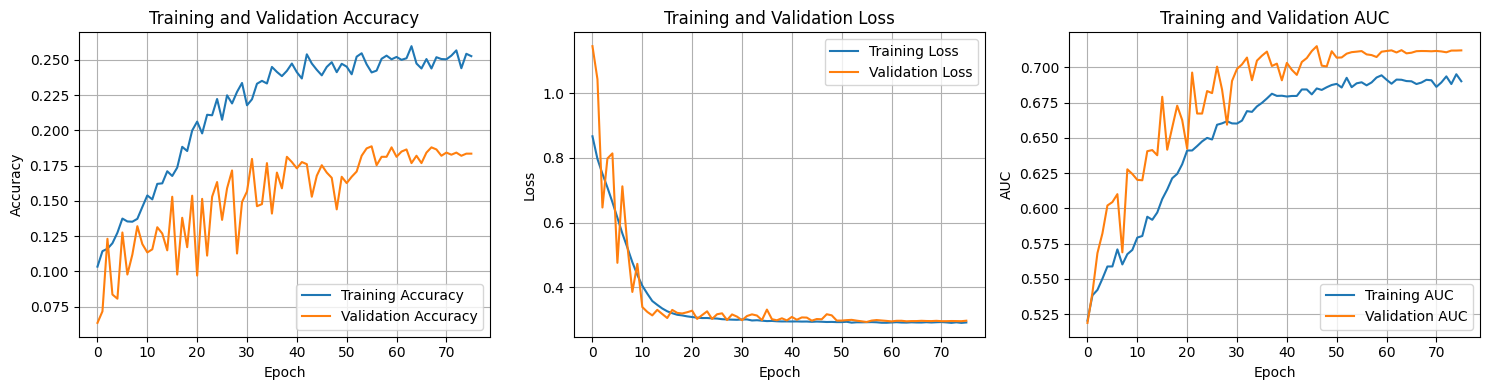

Best epoch: 56
Validation Accuracy: 0.1887
Validation Loss:     0.2924
Validation AUC:      0.7115
------------------------------
Training Accuracy:   0.2411
Training Loss:       0.2917


In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))  # Change: fit new AUC plot

plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'],     label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch');  plt.ylabel('Accuracy');  plt.legend();  plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch');  plt.ylabel('Loss');  plt.legend();  plt.grid(True)

# Change: added AUC plot = tracks how well the model ranks instruments overall (unaffected by the choice of threshold)
plt.subplot(1, 3, 3)
plt.plot(history.history['auc'],     label='Training AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('Training and Validation AUC')
plt.xlabel('Epoch');  plt.ylabel('AUC');  plt.legend();  plt.grid(True)

plt.tight_layout()
plt.show()

best_epoch = np.argmin(history.history['val_loss'])
print(f"Best epoch: {best_epoch + 1}")
print(f"Validation Accuracy: {history.history['val_accuracy'][best_epoch]:.4f}")
print(f"Validation Loss:     {history.history['val_loss'][best_epoch]:.4f}")
print(f"Validation AUC:      {history.history['val_auc'][best_epoch]:.4f}")  # Change: added AUC
print("-" * 30)
print(f"Training Accuracy:   {history.history['accuracy'][best_epoch]:.4f}")
print(f"Training Loss:       {history.history['loss'][best_epoch]:.4f}")

In [77]:
from sklearn.metrics import f1_score

# (Added in v4)
def find_optimal_thresholds(y_true, y_pred_probs, val_data):
    """Find best threshold per class using validation set"""
    optimal_thresholds = []
    
    for i in range(NUM_CLASSES):
        best_f1 = 0
        best_thresh = 0.2  # default
        
        for thresh in np.arange(0.1, 0.6, 0.05):
            y_pred_binary = (y_pred_probs[:, i] > thresh).astype(int)
            f1 = f1_score(y_true[:, i], y_pred_binary)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh
                
        optimal_thresholds.append(best_thresh)
        print(f"{instrument_list[i]}: threshold={best_thresh:.3f}, F1={best_f1:.3f}")
    
    return optimal_thresholds

In [78]:
## THRESHOLD IS THE CONFIDENCE BAR WHICH DECIDES IF THERE IS AN X INSTRUMENT IN THE SAMPLE.
## WE HAVE 11 INSTRUMENTS SO RANDOM GUESSING WOULD BE AROUND 0.09.
## SO IF WE HAVE THRESHOLD OF 0.20 IT NEEDS TO HAVE ATLEAST 0.20 PROBABILITY TO BE FLAGGED
## THAT THE INSTRUMENT IS IN THE SAMPLE.

# Change: returns a probability vector (11,) instead of a single float for one instrument -> all instruments are evaluated in one pass per file
from sklearn.metrics import f1_score, roc_auc_score

def find_optimal_thresholds(y_true, y_pred_probs):
    """Find best threshold per class using validation set"""
    optimal_thresholds = []
    
    for i in range(NUM_CLASSES):
        best_f1 = 0
        best_thresh = 0.2
        
        for thresh in np.arange(0.1, 0.6, 0.05):
            y_pred_binary = (y_pred_probs[:, i] > thresh).astype(int)
            f1 = f1_score(y_true[:, i], y_pred_binary)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh
                
        optimal_thresholds.append(best_thresh)
        print(f"{instrument_list[i]}: threshold={best_thresh:.3f}, F1={best_f1:.3f}")
    
    return optimal_thresholds

# Get predictions on validation set for threshold tuning
val_pred_probs = model.predict(val_features, verbose=0)
optimal_thresholds = find_optimal_thresholds(val_labels_extracted, val_pred_probs)

# Get predictions on test set
test_pred_probs = model.predict(test_features, verbose=0)
test_pred_binary = (test_pred_probs > optimal_thresholds).astype(int)

cel: threshold=0.100, F1=0.187
cla: threshold=0.150, F1=0.268
flu: threshold=0.200, F1=0.204
gac: threshold=0.300, F1=0.376
gel: threshold=0.100, F1=0.228
org: threshold=0.100, F1=0.288
pia: threshold=0.150, F1=0.259
sax: threshold=0.100, F1=0.058
tru: threshold=0.100, F1=0.343
vio: threshold=0.100, F1=0.282
voi: threshold=0.100, F1=0.213


In [79]:
# RECALL    = "Of all the X instruments in the test set, how many did the model actually find?"
# PRECISION = "When the model says it's a X instrument, how often is it actually a X instrument?"
# F1 SCORE  = harmonic mean of precision and recall "The balance of the two"

# Classification report
print(f"\nMultilabel Classification Report on TEST set (VGG16 + SpecAugment):\n")
print(classification_report(
    test_labels_extracted,
    test_pred_binary,
    target_names=[instrument_map[k] for k in instrument_list]
))


Multilabel Classification Report on TEST set (VGG16 + SpecAugment):

                 precision    recall  f1-score   support

        Celesta       0.04      0.58      0.08       111
       Clarinet       0.07      0.27      0.12        62
          Flute       0.14      0.18      0.16       163
Acoustic Guitar       0.54      0.07      0.13       535
Electric Guitar       0.57      0.20      0.29       942
          Organ       0.12      0.21      0.15       361
          Piano       0.36      0.46      0.40       995
      Saxophone       0.12      0.01      0.01       326
        Trumpet       0.12      0.09      0.10       167
         Violin       0.47      0.31      0.37       211
    Human Voice       0.53      0.10      0.16      1044

      micro avg       0.22      0.21      0.22      4917
      macro avg       0.28      0.22      0.18      4917
   weighted avg       0.40      0.21      0.22      4917
    samples avg       0.19      0.24      0.20      4917



e:\KOULU\Neural-Networks-Project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [80]:
# AUC score
auc_score = roc_auc_score(test_labels_extracted, test_pred_probs, average='macro')
print(f"Test AUC: {auc_score:.4f}")

Test AUC: 0.6478


In [81]:
model.save("irmas_instrument_classifier_v3_multilabel_data_aug_pretrained.keras")
print("Model saved.")

Model saved.


Disappointing performance, since firstly: input shape is not matching 244x244 of VGG16, secondly: VGG16 is trained to recognize shapes like eyes, faces etc. and is ill suited for spectrogram feature extraction. 